# Setup

In [1]:
# standard library imports
import time

# third party library imports
import numpy as np
import optuna
import pandas as pd

# machine learning imports
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    log_loss,
    make_scorer,
    matthews_corrcoef,
    roc_auc_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    FunctionTransformer,
    LabelEncoder,
    OneHotEncoder,
    OrdinalEncoder,
    RobustScaler,
    TargetEncoder,
)
from sklearn.svm import SVC, LinearSVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

# local imports
from utils import (
    adversarial_score,
    barplot,
    countplot,
    heatmap,
    histplot,
    kdeplot,
    lineplot,
    scatterplot,
    subplots,
)

In [2]:
# patch sklearn for performance boost
from sklearnex import patch_sklearn

patch_sklearn(verbose=False)

# EDA

In [3]:
# load data
index_col = "id"
train_data = pd.read_csv("train.csv", index_col=index_col)
test_data = pd.read_csv("test.csv", index_col=index_col)
sub_data = pd.read_csv("sample_submission.csv", index_col=index_col)

In [4]:
# preview data
train_data

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
id,,,,,,,,,,,,,,,,,,,,
0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,16.79,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,3.39,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,3.85,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,2.31,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,13.94,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
629995,Clay,6.54,13.45,1.15,1.86,26.65,26.86,1041.33,10.62,18.85,Rice,Sowing,Kharif,Sprinkler,River,4.35,No,118.36,South,Medium
629996,Clay,7.03,54.49,0.96,2.35,36.99,88.00,1419.57,9.93,17.99,Sugarcane,Vegetative,Kharif,Drip,Groundwater,12.97,Yes,40.75,Central,Medium
629997,Clay,6.52,11.98,0.93,0.38,37.82,70.98,88.45,8.19,17.25,Potato,Vegetative,Zaid,Canal,Reservoir,13.58,Yes,2.62,South,High


In [5]:
# check data types
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Soil_Type                630000 non-null  str    
 1   Soil_pH                  630000 non-null  float64
 2   Soil_Moisture            630000 non-null  float64
 3   Organic_Carbon           630000 non-null  float64
 4   Electrical_Conductivity  630000 non-null  float64
 5   Temperature_C            630000 non-null  float64
 6   Humidity                 630000 non-null  float64
 7   Rainfall_mm              630000 non-null  float64
 8   Sunlight_Hours           630000 non-null  float64
 9   Wind_Speed_kmh           630000 non-null  float64
 10  Crop_Type                630000 non-null  str    
 11  Crop_Growth_Stage        630000 non-null  str    
 12  Season                   630000 non-null  str    
 13  Irrigation_Type          630000 non-null  str    
 14  Water_Source   

In [6]:
# check for missing values in each column
train_data.isna().sum().sort_values(ascending=False)

Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0
Humidity                   0
Rainfall_mm                0
Sunlight_Hours             0
Wind_Speed_kmh             0
Crop_Type                  0
Crop_Growth_Stage          0
Season                     0
Irrigation_Type            0
Water_Source               0
Field_Area_hectare         0
Mulching_Used              0
Previous_Irrigation_mm     0
Region                     0
Irrigation_Need            0
dtype: int64

In [7]:
# check for unique values
train_data.nunique()

Soil_Type                      4
Soil_pH                      341
Soil_Moisture               5223
Organic_Carbon               131
Electrical_Conductivity      341
Temperature_C               2934
Humidity                    6475
Rainfall_mm                19308
Sunlight_Hours               701
Wind_Speed_kmh              1935
Crop_Type                      6
Crop_Growth_Stage              4
Season                         3
Irrigation_Type                4
Water_Source                   4
Field_Area_hectare          1466
Mulching_Used                  2
Previous_Irrigation_mm     10110
Region                         5
Irrigation_Need                3
dtype: int64

Irrigation_Need
Low       58.717
Medium    37.948
High       3.335
Name: proportion, dtype: float64

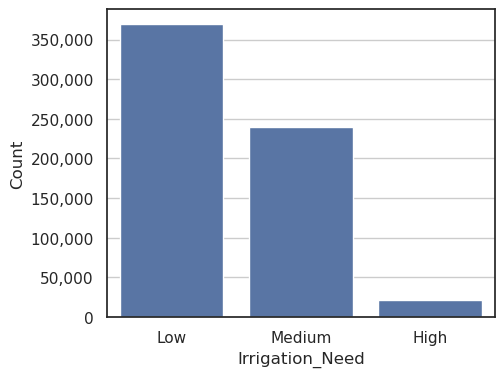

In [8]:
# set target and classes
target = "Irrigation_Need"
target_classes = [
    "Low",
    "Medium",
    "High",
]
ax = countplot(x=train_data[target])
train_data[target].describe()
train_data[target].value_counts(normalize=True) * 100

In [9]:
# process data
def process_data(df: pd.DataFrame) -> pd.DataFrame:
    new_df = df.copy()

    new_df["Soil_Moisture_lt_25"] = (new_df["Soil_Moisture"] < 25).astype(np.float32)
    new_df["Temperature_gt_30"] = (new_df["Temperature_C"] > 30).astype(np.float32)
    new_df["Rainfall_lt_300"] = (new_df["Rainfall_mm"] < 300).astype(np.float32)
    new_df["Wind_Speed_gt_10"] = (new_df["Wind_Speed_kmh"] > 10).astype(np.float32)
    new_df["Mulching_Used"] = (new_df["Mulching_Used"] == "Yes").astype(np.float32)
    for stage in ["Flowering", "Harvest", "Sowing", "Vegetative"]:
        new_df[stage] = (new_df["Crop_Growth_Stage"] == stage).astype(np.float32)

    drop = [
        "Crop_Growth_Stage",
        "Crop_Type",
        "Electrical_Conductivity",
        "Field_Area_hectare",
        "Humidity",
        "Organic_Carbon",
        "Previous_Irrigation_mm",
        "Rainfall_mm",
        "Region",
        "Season",
        "Irrigation_Type",
        "Soil_Moisture",
        "Soil_pH",
        "Soil_Type",
        "Sunlight_Hours",
        "Temperature_C",
        "Water_Source",
        "Wind_Speed_kmh",
    ]
    return new_df.drop(columns=drop)


train_data = process_data(train_data)
test_data = process_data(test_data)

In [10]:
# set features
numerical_features = [
    "Flowering",
    "Harvest",
    "Mulching_Used",
    "Rainfall_lt_300",
    "Soil_Moisture_lt_25",
    "Sowing",
    "Temperature_gt_30",
    "Vegetative",
    "Wind_Speed_gt_10",
]

features = numerical_features
plot_features = features
corr_features = [target] + features

In [11]:
# use copies for exploratory analysis
train_data_encoded = train_data.copy()
test_data_encoded = test_data.copy()

# encode target
target_encoder = LabelEncoder().fit(train_data[target])
train_data_encoded[target] = np.asarray(target_encoder.transform(train_data[target]))

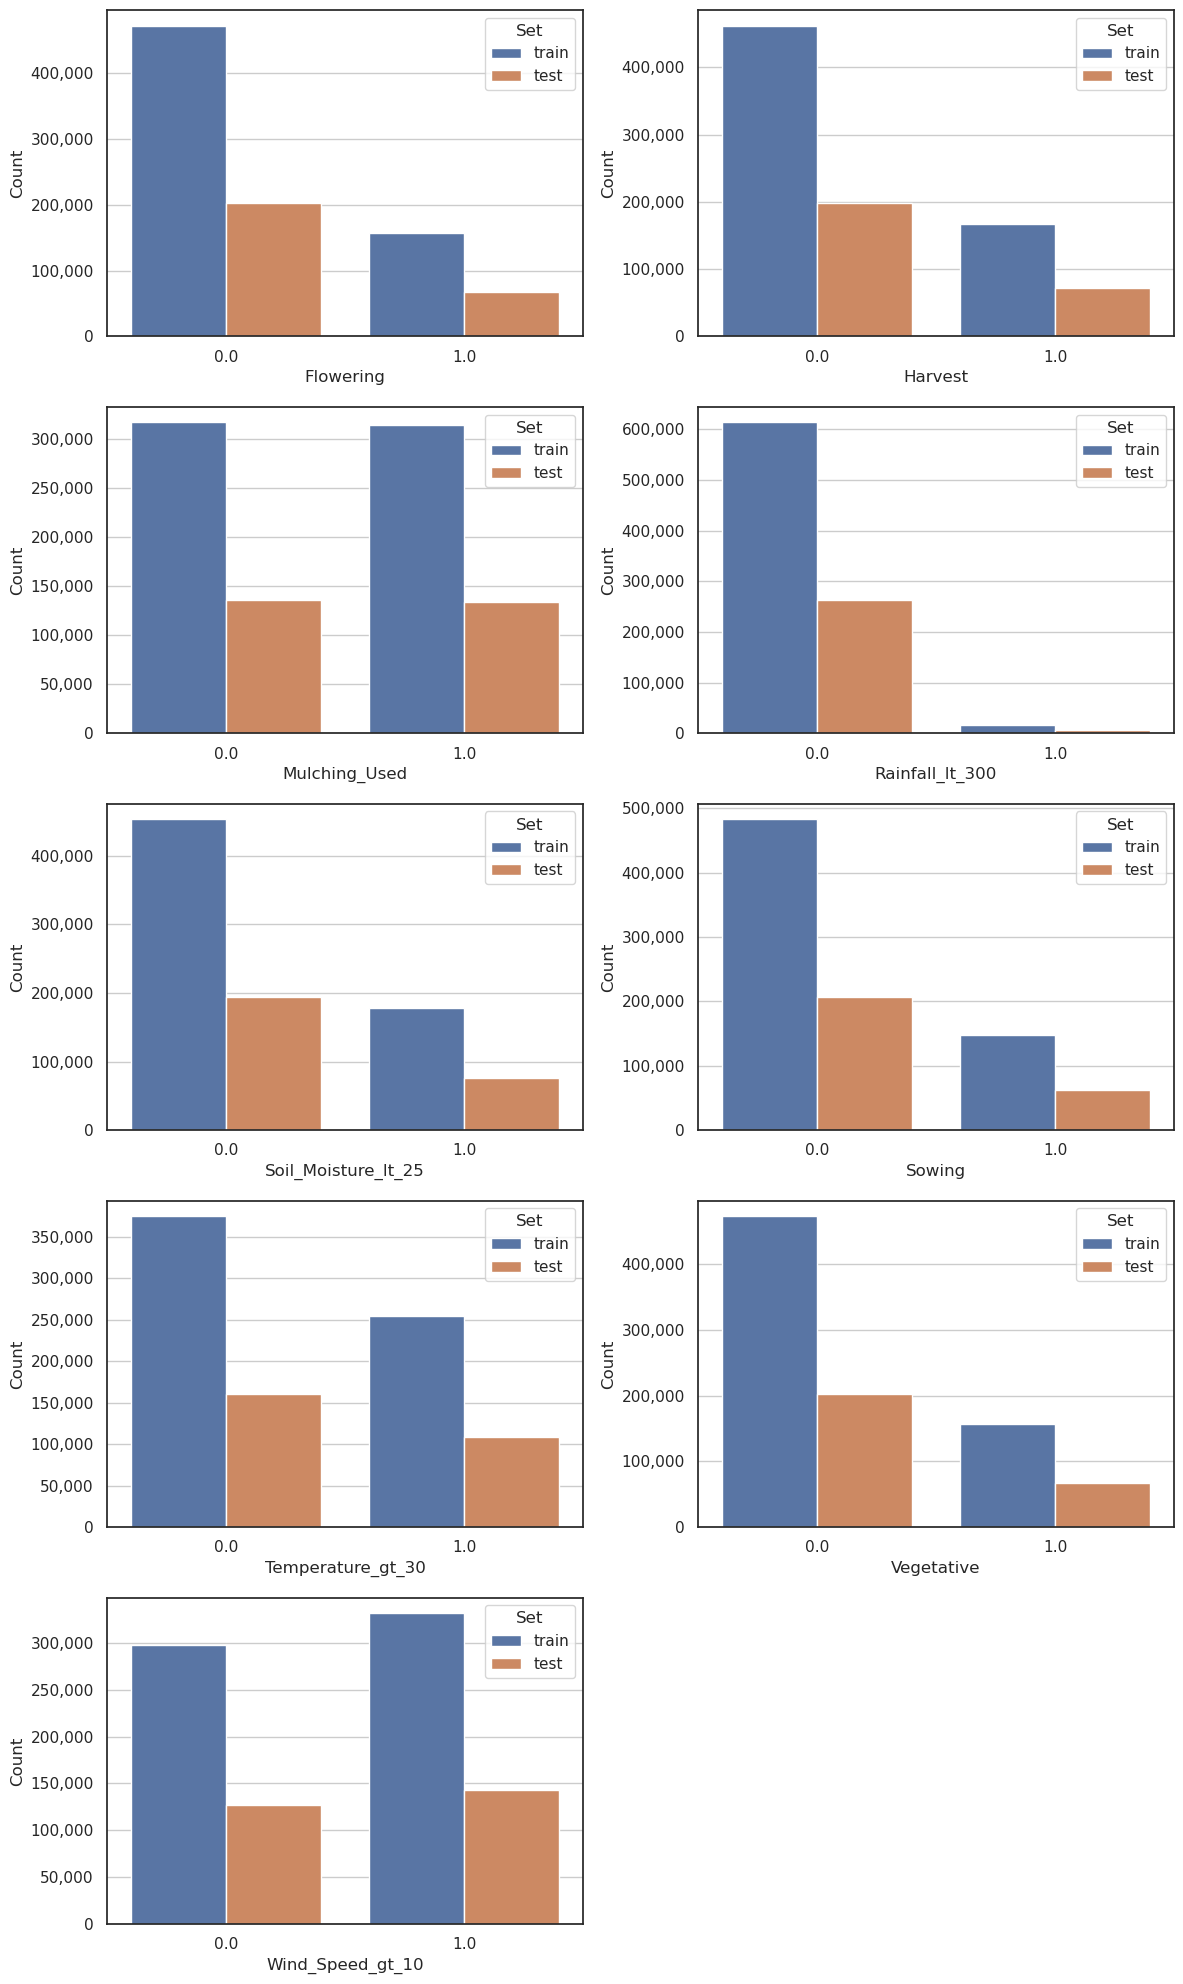

In [12]:
# plot features
unmerged_data = [train_data.assign(Set="train"), test_data.assign(Set="test")]
merged_data = pd.concat(unmerged_data, ignore_index=True, join="inner")
feature_groups = [(numerical_features, countplot)]
fig, axes = subplots(feature_groups, data=merged_data, hue="Set")

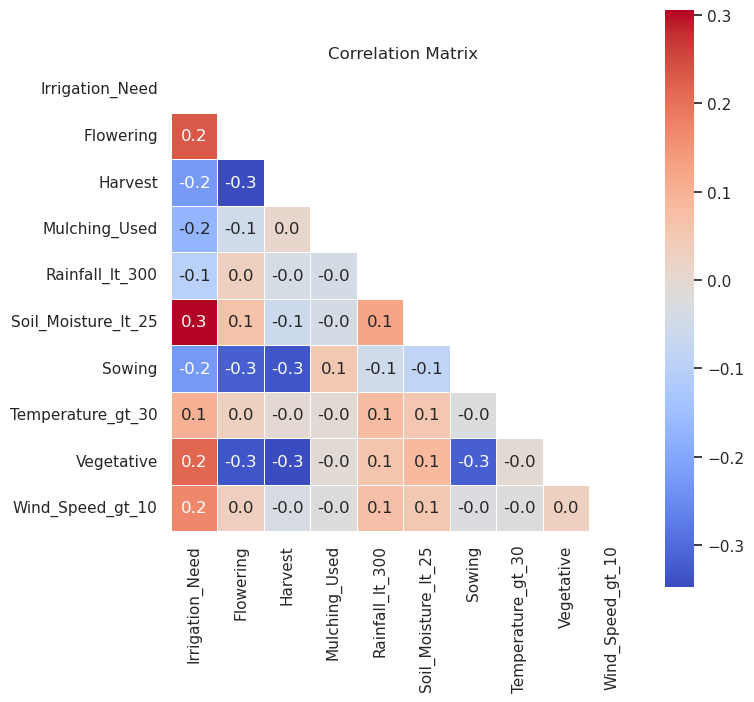

In [13]:
# plot correlations
corr = train_data_encoded[corr_features].corr()
ax = heatmap(data=corr, mask=np.triu(corr))
_ = ax.set_title("Correlation Matrix")

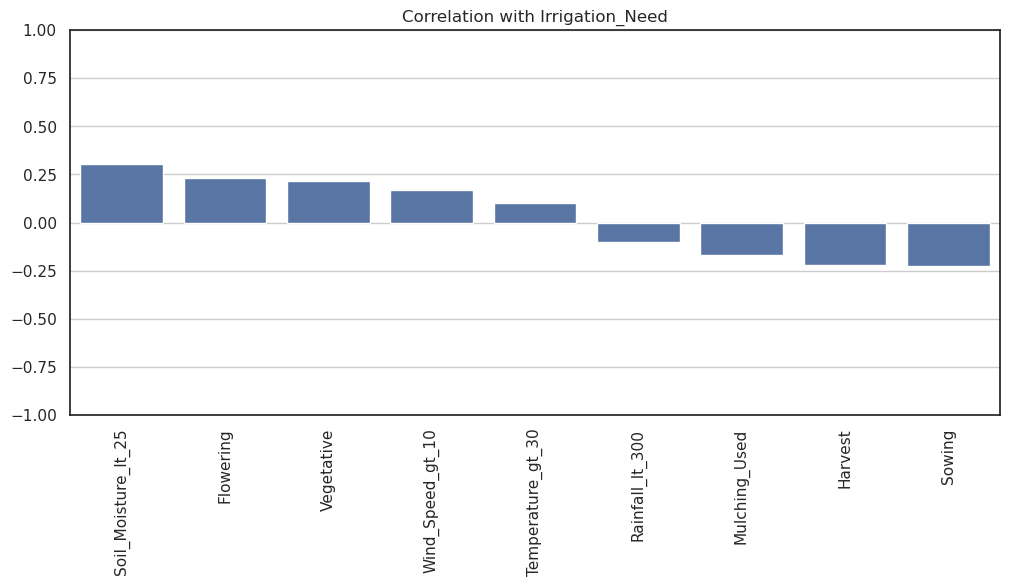

In [14]:
# plot target correlations
corrwith = corr[target].drop(target).sort_values(ascending=False)

ax = barplot(x=corrwith.index, y=corrwith.to_numpy(), rotation=90)
_ = ax.set_xlabel("")
_ = ax.set_ylim(-1, 1)
_ = ax.set_title(f"Correlation with {target}")

In [15]:
# validate that train and test sets have similar distributions
score = adversarial_score(data=merged_data, model=LGBMClassifier(verbose=-1))

threshold = 0.6
comp = "<" if score < threshold else ">="
message = "indistinguishable" if score < threshold else "distinguishable"
print(f"Score = {score:.2f} {comp} threshold = {threshold} → distributions {message}")

Score = 0.50 < threshold = 0.6 → distributions indistinguishable


# Data Preprocessing

In [16]:
# encode target
train_data[target] = train_data_encoded[target]

# split data into training and test sets
X = train_data[features]
y = train_data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
# define preprocessing columns and steps
transformer_config = {
    "numerical": {
        "columns": numerical_features,
        "steps": [("passthrough", "passthrough")],
    },
}

In [18]:
# build preprocessor
transformers = []
for feature_type, config in transformer_config.items():
    columns = config["columns"]
    steps = config["steps"]
    feature_pipeline = Pipeline(steps=steps)
    transformers.append((feature_type, feature_pipeline, columns))

preprocessor = ColumnTransformer(transformers=transformers)
preprocessor.set_output(transform="pandas")

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feat

In [19]:
# define scoring metrics
metrics = {
    "balanced_accuracy": {
        "func": balanced_accuracy_score,
    },
}

primary_metric = "balanced_accuracy"
primary_scorer = make_scorer(
    score_func=metrics[primary_metric]["func"],
    response_method="predict",
)

# Modelling

In [20]:
# create models and parameter spaces
models = {
    "decision": {
        "model": DecisionTreeClassifier(
            class_weight="balanced",
            criterion="entropy",
            random_state=42,
            splitter="random",
        ),
        "params": {
            "decision__ccp_alpha": ("float", 1e-6, 1e-4, {"log": True}),
        },
    },
    "lgb": {
        "model": LGBMClassifier(
            colsample_bytree=1,
            class_weight="balanced",
            min_child_samples=1,
            n_estimators=1,
            random_state=42,
            verbose=-1,
        ),
        "params": {
            "lgb__num_leaves": ("int", 2**6, 2**7, {"log": True}),
        },
    },
    "linear_svc": {
        "model": LinearSVC(
            class_weight="balanced",
            fit_intercept=False,
            max_iter=1_000_000,
            multi_class="crammer_singer",
        ),
        "params": {
            "linear_svc__C": ("float", 1e0, 1e1, {"log": True}),
        },
    },
    "lr": {
        "model": LogisticRegression(
            class_weight="balanced",
            fit_intercept=True,
            max_iter=10_000,
            random_state=42,
            solver="lbfgs",
        ),
        "params": {
            "lr__C": ("float", 1e-2, 2e-1, {"log": True}),
        },
    },
}

In [21]:
# train all models with default parameters on X_train
train_results_list = []
train_times = {}
pipelines = {}

cv_train = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for model_name, model_config in models.items():
    pipeline = Pipeline(
        [
            ("preprocessor", preprocessor),
            (model_name, model_config["model"]),
        ],
    )

    start_time = time.time()
    search = GridSearchCV(
        estimator=pipeline,
        param_grid={},
        cv=cv_train,
        scoring=primary_scorer,
        refit=True,
    )
    search.fit(X_train, y_train)
    elapsed_time = time.time() - start_time

    cv_scores = {primary_metric: search.cv_results_["mean_test_score"][0]}
    cv_scores["model"] = model_name

    pipelines[model_name] = search.best_estimator_
    train_times[model_name] = elapsed_time
    train_results_list.append(cv_scores)

train_results = pd.DataFrame(train_results_list).set_index("model")
train_results = train_results.sort_values(primary_metric, ascending=False)
best_model_name = str(train_results[primary_metric].idxmax())
display(train_results)

,balanced_accuracy
model,
decision,0.964
lr,0.962
lgb,0.962
linear_svc,0.962


In [22]:
# define objective function for tuning
def make_objective(model_name, cv, metric, X, y):
    def objective(trial):
        param_space = models[model_name]["params"]
        params = {}
        for param_name, spec in param_space.items():
            suggest_type, low, high, kwargs = spec
            if suggest_type == "int":
                params[param_name] = trial.suggest_int(param_name, low, high, **kwargs)
            elif suggest_type == "float":
                params[param_name] = trial.suggest_float(
                    param_name, low, high, **kwargs
                )
            elif suggest_type == "categorical":
                params[param_name] = trial.suggest_categorical(param_name, low)

        trial_pipeline = clone(pipelines[model_name])
        trial_pipeline.set_params(**params)

        scores = []
        for train_idx, val_idx in cv.split(X, y):
            X_fold_train, X_fold_val = X.iloc[train_idx], X.iloc[val_idx]
            y_fold_train, y_fold_val = y.iloc[train_idx], y.iloc[val_idx]
            trial_pipeline.fit(X_fold_train, y_fold_train)
            y_fold_pred = trial_pipeline.predict(X_fold_val)
            scores.append(metrics[metric]["func"](y_fold_val, y_fold_pred))

        return sum(scores) / len(scores)

    return objective

In [23]:
# tune all models on X_train
cv_tune = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

studies_X_train = {}

for model_name in models:
    start_time = time.time()

    study = optuna.create_study(
        direction="maximize", sampler=optuna.samplers.TPESampler(seed=42)
    )
    study.optimize(
        make_objective(model_name, cv_tune, primary_metric, X_train, y_train),
        n_trials=15,
        show_progress_bar=True,
    )

    elapsed_time = time.time() - start_time
    params = study.best_params

    pipeline = clone(pipelines[model_name])
    pipeline.set_params(**params)
    pipeline.fit(X_train, y_train)

    pipelines[f"{model_name}_X_train"] = pipeline
    train_times[f"{model_name}_X_train"] = elapsed_time
    studies_X_train[model_name] = study

Best trial: 10. Best value: 0.96241: 100%|██████████| 15/15 [03:35<00:00, 14.40s/it]


In [24]:
# evaluate all models on X_test
test_results_list = []
confusion_matrices = {}

for model_name, pipeline in pipelines.items():
    y_test_pred = pipeline.predict(X_test)

    test_scores = {}
    for metric_name, metric_config in metrics.items():
        test_scores[metric_name] = metric_config["func"](y_test, y_test_pred)

    test_scores["model"] = model_name
    test_results_list.append(test_scores)

    confusion_matrices[model_name] = confusion_matrix(y_test, y_test_pred)

test_results = pd.DataFrame(test_results_list).set_index("model")
test_results["train_time"] = pd.Series(train_times)
test_results = test_results.sort_values(primary_metric, ascending=False)

display(test_results)

,balanced_accuracy,train_time
model,,
decision,0.962,1.509
decision_X_train,0.962,18.909
lgb_X_train,0.962,14.463
lr,0.961,10.519
lr_X_train,0.961,215.927
linear_svc,0.961,16.478
linear_svc_X_train,0.961,586.679
lgb,0.961,1.158


In [25]:
# tune all models on X
cv_tune = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

studies_X = {}

for model_name in models:
    start_time = time.time()

    study = optuna.create_study(
        direction="maximize", sampler=optuna.samplers.TPESampler(seed=42)
    )
    study.optimize(
        make_objective(model_name, cv_tune, primary_metric, X, y),
        n_trials=15,
        show_progress_bar=True,
    )

    elapsed_time = time.time() - start_time
    params = study.best_params

    pipeline = clone(pipelines[model_name])
    pipeline.set_params(**params)
    pipeline.fit(X, y)

    pipelines[f"{model_name}_X"] = pipeline
    train_times[f"{model_name}_X"] = elapsed_time
    studies_X[model_name] = study

Best trial: 11. Best value: 0.962187: 100%|██████████| 15/15 [04:14<00:00, 16.99s/it]


In [26]:
# print best scores and params
for model_name, study in studies_X.items():
    print(f"{model_name}: {study.best_value:.4f} — {study.best_params}")

decision: 0.9633 — {'decision__ccp_alpha': 2.05133826308745e-06}
lgb: 0.9634 — {'lgb__num_leaves': 83}
linear_svc: 0.9616 — {'linear_svc__C': 8.927180304353628}
lr: 0.9622 — {'lr__C': 0.02731036471075642}


In [27]:
# retrain tuned model on X_train and X_test
tuned_model_name = "lgb"
final_model = pipelines[tuned_model_name]
# final_model.fit(X, y)

# Results

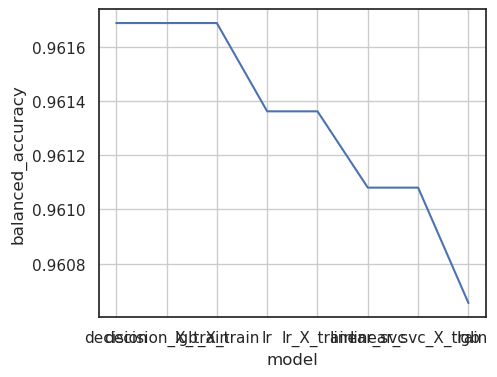

In [28]:
# plot initial results
ax = lineplot(data=test_results.reset_index(), x="model", y=primary_metric)

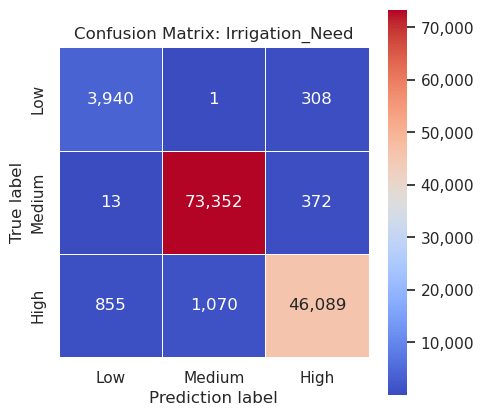

In [29]:
# plot confusion matrix
cm = pd.DataFrame(
    confusion_matrices[tuned_model_name], columns=target_classes, index=target_classes
)
ax = heatmap(data=cm, fmt=",.0f")
_ = ax.set_xlabel("Prediction label")
_ = ax.set_ylabel("True label")
_ = ax.set_title(f"Confusion Matrix: {target}")

In [30]:
# make predictions and probabilties
test_pred = final_model.predict(test_data)
test_pred_proba = final_model.predict_proba(test_data)[:, 1]
decoded_pred = target_encoder.inverse_transform(test_pred.ravel())

# write to submissions file
sub_data[target] = decoded_pred
sub_data.to_csv("submission.csv", index=True, index_label=index_col)

pd.read_csv("submission.csv")

,id,Irrigation_Need
0,630000,Low
1,630001,Low
2,630002,Low
3,630003,Low
4,630004,Low
...,...,...
269995,899995,Medium
269996,899996,Low
269997,899997,Medium
269998,899998,Low


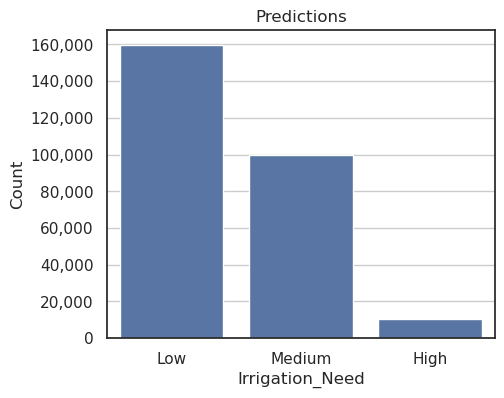

In [31]:
# plot predictions/probabilities
ax = countplot(x=sub_data[target])
_ = ax.set_title("Predictions")